# Analisis factorial: el TDA y las exogenas, ¿ayudan?

Este notebook **lee los resultados ya generados** (`factorial_long.csv`,
`analisis_pruebas_pareadas.csv`, `analisis_regresion.csv`) y produce las tablas
y figuras finales para el reporte. No recalcula el barrido (eso lo hizo
`run_full_factorial` desde terminal, ~25,600 combinaciones x 4 folds).

**Pregunta central:** ¿usar caracteristicas topologicas (TDA) o variables
exogenas mejora el pronostico de WPUSI01102B de forma estadisticamente
significativa?

**Metodologia:** las pruebas se hacen sobre los folds de TimeSeriesSplit
(validacion cruzada). El test 2022+ queda intacto y se evalua aparte.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})
# Paleta del proyecto
C = {"tda": "#534AB7", "notda": "#888780", "exog": "#1D9E75",
     "bad": "#D85A30", "good": "#1D9E75", "blue": "#378ADD"}

PROC = "../data/processed"
FIG  = "../reports/figures"
import os; os.makedirs(FIG, exist_ok=True)

In [2]:
# Autodeteccion de la raiz del proyecto (funciona desde notebooks/ o notebooks/<sub>/)
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT/"data"/"interim").exists():
    ROOT = ROOT.parent
DATA   = str(ROOT/"data"/"interim"/"berry_features.csv")
PROC   = str(ROOT/"data"/"processed")
MODELS = str(ROOT/"models")
FIG    = str(ROOT/"reports"/"figures")
import os; os.makedirs(FIG, exist_ok=True)
print("ROOT:", ROOT)

ROOT: /home/makenly/Escritorio/berry-price-tda


## 1. Carga de resultados

In [3]:
df_long = pd.read_csv(f"{PROC}/factorial_long.csv")
pareadas = pd.read_csv(f"{PROC}/analisis_pruebas_pareadas.csv")
reg = pd.read_csv(f"{PROC}/analisis_regresion.csv", index_col=0)

df_long["has_exog"] = df_long["n_exog"] > 0
print(f"Combinaciones x fold: {len(df_long):,}")
print(f"Combinaciones unicas: {df_long['__label__'].nunique():,}")
print(f"Modelos: {sorted(df_long['modelo'].unique())}")
print(f"Ventanas: {sorted(df_long['window'].unique())} | "
      f"Transforms: {list(df_long['transform'].unique())}")
df_long.head()

Combinaciones x fold: 87,040
Combinaciones unicas: 25,600
Modelos: ['DecisionTree', 'ElasticNet', 'GradientBoosting', 'KNN', 'Lasso', 'LinearRegression', 'Ridge', 'SVR_rbf']
Ventanas: [12, 24, 36, 48] | Transforms: ['none', 'standard', 'diff', 'log_diff', 'seasonal_diff']


,modelo,window,transform,exog,n_exog,use_tda,estrategia,fold,mae,rmse,mape,r2,__label__,has_exog
0,LinearRegression,24,none,none,0,False,none,0,22.016116,25.927116,16.603202,0.429143,LinearRegression|w24|none|noexog,False
1,LinearRegression,24,none,none,0,False,none,1,29.778947,32.868539,22.801401,0.235475,LinearRegression|w24|none|noexog,False
2,LinearRegression,24,none,none,0,False,none,2,34.600260,43.454417,28.543259,-0.166247,LinearRegression|w24|none|noexog,False
3,LinearRegression,24,none,none,0,False,none,3,27.630805,37.368522,19.996145,0.032491,LinearRegression|w24|none|noexog,False
4,LinearRegression,24,none,none,0,False,dummy,0,22.016116,25.927116,16.603202,0.429143,LinearRegression|w24|none|noexog|dummy,False


## 2. Top combinaciones (MAE promedio en CV)

Tabla limpia para el reporte: las 10 mejores configuraciones por MAE promedio
entre folds, con su desviacion estandar (estabilidad).

In [4]:
top = (df_long.groupby("__label__")
       .agg(mae_mean=("mae","mean"), mae_std=("mae","std"),
            rmse_mean=("rmse","mean"), r2_mean=("r2","mean"))
       .sort_values("mae_mean").head(10).round(3))
top.index.name = "configuracion"
top.to_csv(f"{PROC}/tabla_top10_cv.csv")
top

,mae_mean,mae_std,rmse_mean,r2_mean
configuracion,,,,
ElasticNet|w12|standard|ppi_+dies+mxn_|tda|isolation,20.891,6.296,28.538,0.394
ElasticNet|w12|standard|ppi_+dies+mxn_|isolation,20.891,6.296,28.538,0.394
ElasticNet|w12|standard|ppi_+mxn_|tda|isolation,20.891,6.296,28.538,0.394
ElasticNet|w12|standard|ppi_+mxn_|isolation,20.891,6.296,28.538,0.394
KNN|w24|none|ppi_+mxn_|isolation,21.012,5.643,28.010,0.427
KNN|w24|standard|ppi_+mxn_|isolation,21.012,5.643,28.010,0.427
KNN|w24|none|cpi_+dies+mxn_|isolation,21.043,5.925,28.249,0.415
KNN|w24|standard|cpi_+dies+mxn_|isolation,21.043,5.925,28.249,0.415
KNN|w24|standard|ppi_+dies+mxn_|isolation,21.155,5.444,27.990,0.430


## 3. Efecto del TDA

In [5]:
# Tabla resumen del efecto TDA (de las pruebas pareadas ya calculadas)
tda_row = pareadas[pareadas["factor"]=="use_tda"].iloc[0]
print("PRUEBA PAREADA - use_tda")
print(f"  Pares comparados   : {int(tda_row['n_pairs']):,}")
print(f"  MAE medio CON TDA  : {tda_row['mean_mae_on']:.3f}")
print(f"  MAE medio SIN TDA  : {tda_row['mean_mae_off']:.3f}")
print(f"  Diferencia media   : {tda_row['mean_diff']:+.3f}  (positivo = TDA empeora)")
print(f"  Wilcoxon p-valor   : {tda_row['p_value']:.2e}")
print(f"  Cliff's delta      : {tda_row['cliffs_delta']:.4f}  -> {tda_row['efecto']}")
print(f"  ¿Ayuda?            : {tda_row['ayuda']}")

PRUEBA PAREADA - use_tda
  Pares comparados   : 43,520
  MAE medio CON TDA  : 33.354
  MAE medio SIN TDA  : 32.591
  Diferencia media   : +0.763  (positivo = TDA empeora)
  Wilcoxon p-valor   : 0.00e+00
  Cliff's delta      : 0.0474  -> insignificante
  ¿Ayuda?            : False


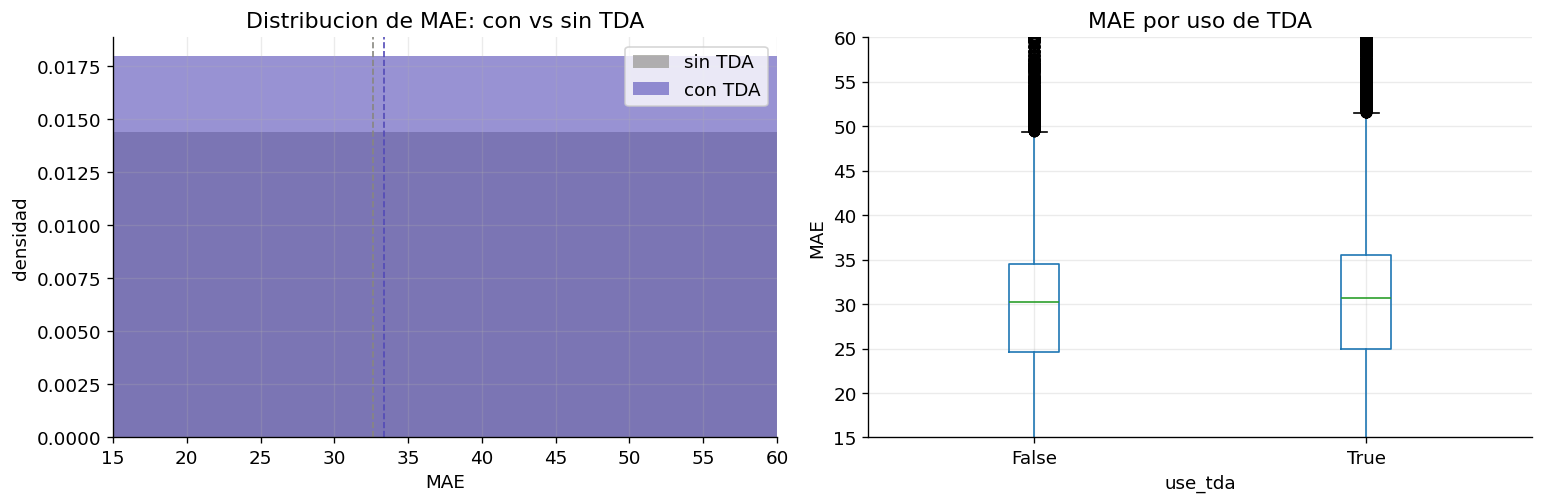

In [6]:
# FIGURA: distribucion de MAE con vs sin TDA
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for val, color, lab in [(False, C["notda"], "sin TDA"), (True, C["tda"], "con TDA")]:
    sub = df_long[df_long["use_tda"]==val]["mae"].dropna()
    axes[0].hist(sub, bins=50, alpha=0.6, color=color, label=lab, density=True)
axes[0].axvline(df_long[~df_long.use_tda].mae.mean(), color=C["notda"], ls="--", lw=1)
axes[0].axvline(df_long[df_long.use_tda].mae.mean(), color=C["tda"], ls="--", lw=1)
axes[0].set(title="Distribucion de MAE: con vs sin TDA", xlabel="MAE", ylabel="densidad")
axes[0].set_xlim(15, 60); axes[0].legend()

df_long.boxplot(column="mae", by="use_tda", ax=axes[1])
axes[1].set(title="MAE por uso de TDA", xlabel="use_tda", ylabel="MAE")
axes[1].set_ylim(15, 60)
plt.suptitle("")
plt.savefig(f"{FIG}/fig_efecto_tda.png", bbox_inches="tight")
plt.show()

## 4. Efecto de las exogenas

In [7]:
exog_row = pareadas[pareadas["factor"]=="has_exog"].iloc[0]
print("PRUEBA PAREADA - has_exog")
print(f"  Pares comparados   : {int(exog_row['n_pairs']):,}")
print(f"  MAE medio CON exog : {exog_row['mean_mae_on']:.3f}")
print(f"  MAE medio SIN exog : {exog_row['mean_mae_off']:.3f}")
print(f"  Diferencia media   : {exog_row['mean_diff']:+.3f}  (positivo = exog empeora)")
print(f"  Wilcoxon p-valor   : {exog_row['p_value']:.2e}")
print(f"  Cliff's delta      : {exog_row['cliffs_delta']:.4f}  -> {exog_row['efecto']}")
print(f"  ¿Ayuda?            : {exog_row['ayuda']}")

PRUEBA PAREADA - has_exog
  Pares comparados   : 5,440
  MAE medio CON exog : 33.129
  MAE medio SIN exog : 30.639
  Diferencia media   : +2.489  (positivo = exog empeora)
  Wilcoxon p-valor   : 2.85e-144
  Cliff's delta      : 0.0812  -> insignificante
  ¿Ayuda?            : False


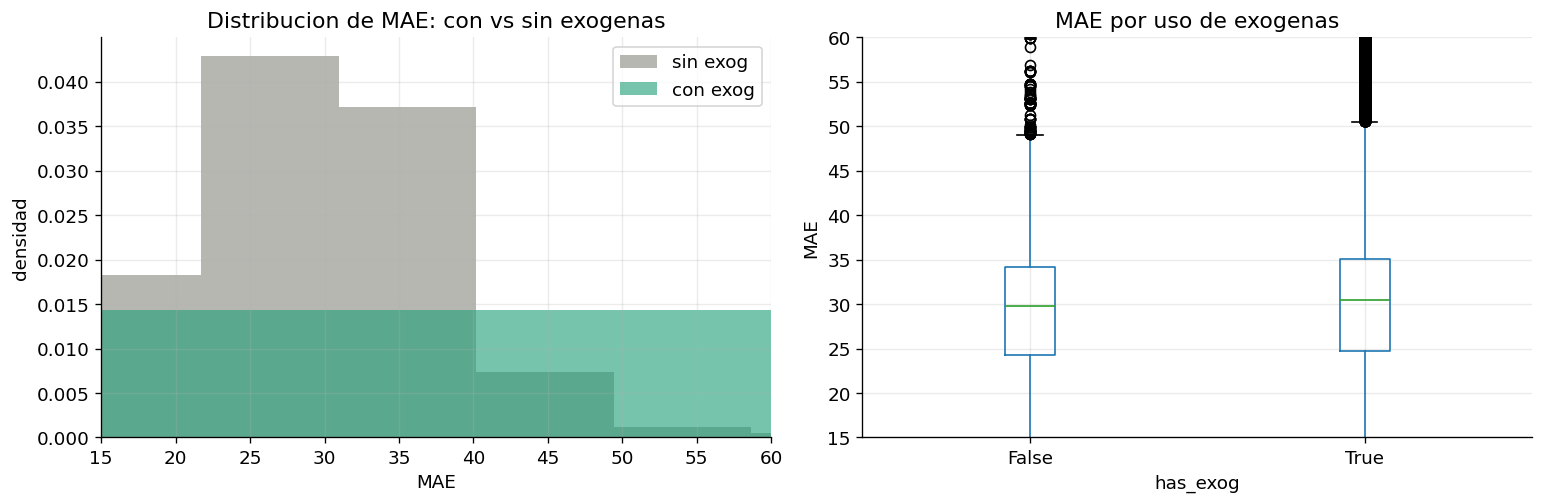

In [8]:
# FIGURA: distribucion de MAE con vs sin exogenas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for val, color, lab in [(False, C["notda"], "sin exog"), (True, C["exog"], "con exog")]:
    sub = df_long[df_long["has_exog"]==val]["mae"].dropna()
    axes[0].hist(sub, bins=50, alpha=0.6, color=color, label=lab, density=True)
axes[0].set(title="Distribucion de MAE: con vs sin exogenas", xlabel="MAE", ylabel="densidad")
axes[0].set_xlim(15, 60); axes[0].legend()

df_long.boxplot(column="mae", by="has_exog", ax=axes[1])
axes[1].set(title="MAE por uso de exogenas", xlabel="has_exog", ylabel="MAE")
axes[1].set_ylim(15, 60)
plt.suptitle("")
plt.savefig(f"{FIG}/fig_efecto_exog.png", bbox_inches="tight")
plt.show()

## 5. Regresion factorial (efecto marginal de cada factor)

Modela el MAE como funcion de TODOS los factores a la vez (equivale a un ANOVA
factorial). El coeficiente de cada factor es su efecto controlando por los
demas. Negativo = reduce el MAE (mejora); positivo = lo aumenta (empeora).

In [9]:
# Tabla de coeficientes ordenada por efecto
reg_show = reg[["coef","std_err","p_value","significativo_0.05"]].copy()
reg_show = reg_show.round({"coef":3,"std_err":3})
reg_show.to_csv(f"{PROC}/tabla_regresion_factorial.csv")
reg_show

,coef,std_err,p_value,significativo_0.05
Intercept,27.022,0.671,0.000000e+00,True
C(modelo)[T.ElasticNet],-5.578,0.458,4.705199e-34,True
C(modelo)[T.GradientBoosting],-5.846,0.458,3.086320e-37,True
C(modelo)[T.KNN],-7.429,0.458,5.180176e-59,True
C(modelo)[T.Lasso],-2.322,0.458,4.041573e-07,True
C(modelo)[T.LinearRegression],16.446,0.458,5.728412e-280,True
C(modelo)[T.Ridge],-2.555,0.458,2.474672e-08,True
C(modelo)[T.SVR_rbf],-7.225,0.458,6.492548e-56,True
C(window)[T.24],3.247,0.303,8.760768e-27,True
C(window)[T.36],4.958,0.323,3.310267e-53,True


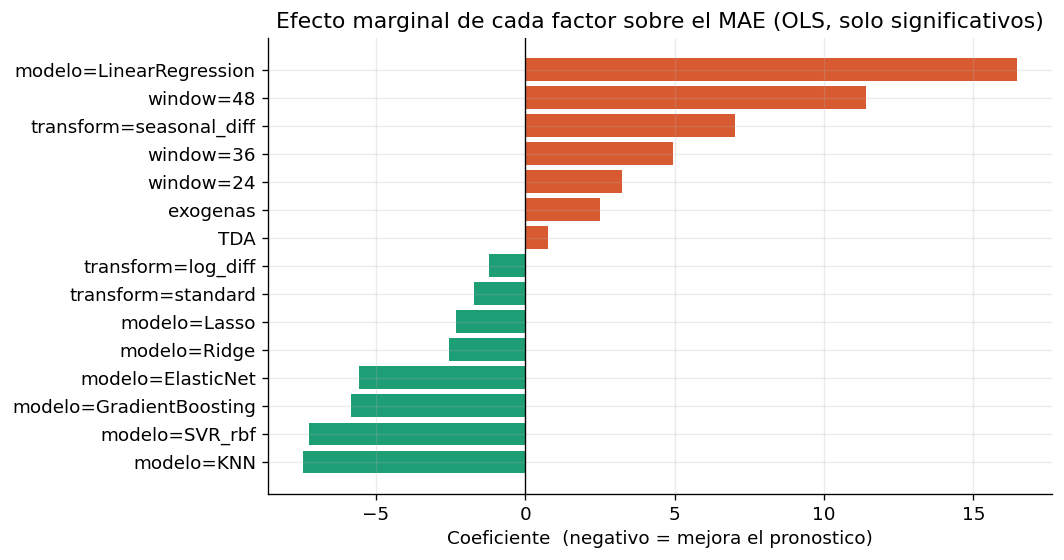

In [10]:
# FIGURA: coeficientes significativos (sin el intercepto)
sig = reg[reg["significativo_0.05"]].drop("Intercept", errors="ignore").copy()
sig = sig.sort_values("coef")
# nombres legibles
sig.index = (sig.index.str.replace(r"C\((\w+)\)\[T\.(\w+)\]", r"\1=\2", regex=True)
                       .str.replace("use_tda", "TDA").str.replace("has_exog", "exogenas"))
colors = [C["bad"] if v > 0 else C["good"] for v in sig["coef"]]

fig, ax = plt.subplots(figsize=(9, max(4, len(sig)*0.32)))
ax.barh(sig.index, sig["coef"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Efecto marginal de cada factor sobre el MAE (OLS, solo significativos)",
       xlabel="Coeficiente  (negativo = mejora el pronostico)")
plt.savefig(f"{FIG}/fig_regresion_factorial.png", bbox_inches="tight")
plt.show()

## 6. Vista por factor individual (medias marginales)

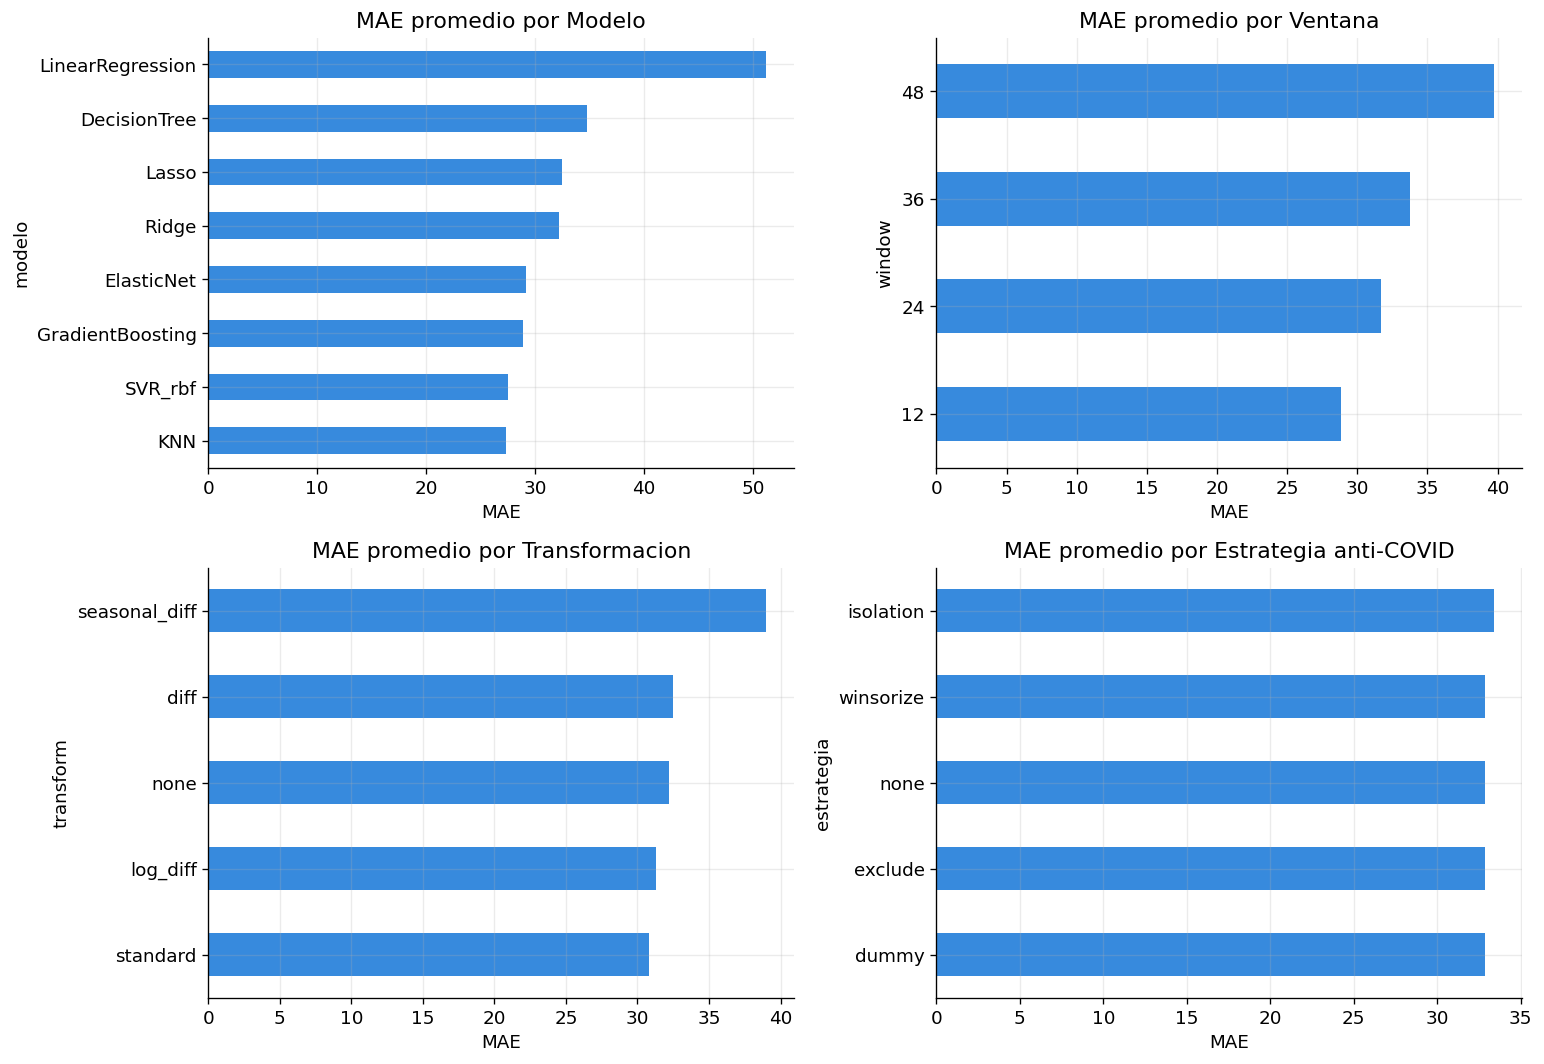

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, fac, ttl in [(axes[0,0],"modelo","Modelo"), (axes[0,1],"window","Ventana"),
                     (axes[1,0],"transform","Transformacion"), (axes[1,1],"estrategia","Estrategia anti-COVID")]:
    s = df_long.groupby(fac)["mae"].mean().sort_values()
    s.plot(kind="barh", ax=ax, color=C["blue"])
    ax.set(title=f"MAE promedio por {ttl}", xlabel="MAE")
plt.savefig(f"{FIG}/fig_factores_individuales.png", bbox_inches="tight")
plt.show()

## 7. Conclusiones (con sustento estadistico)

Las celdas anteriores permiten afirmar, con respaldo numerico:

- **TDA:** la diferencia con/sin TDA es estadisticamente detectable por el enorme
  numero de pares (Wilcoxon p < 0.001), pero el **tamano de efecto es
  insignificante** (Cliff's delta ≈ 0.05) y el signo es *adverso* (coef +0.76 en
  la regresion). Conclusion practica: **el TDA no aporta** para esta serie.
- **Exogenas:** efecto significativo y adverso (coef +2.49, p ≈ 1e-7). Las
  exogenas, agregadas asi, **empeoran** el pronostico.
- **Factores que sí importan:** ventana corta (12 meses mejor que 48),
  transformacion `standard`/`log_diff`, y la familia de modelos lineales
  regularizados.

> Todo lo anterior es sobre los folds de CV. El desempeno honesto en test 2022+
> se reporta en `optuna_optimizacion.ipynb` y `forecasting_factorial.ipynb`.